# 06 · Cross-Model Evaluation

Side-by-side comparison of CF, SVD, and Two-Tower across all ranking metrics (Precision, Recall, NDCG, HitRate, MAP, MRR), coverage, novelty, and rating-prediction error.

In [1]:
import sys

sys.path.insert(0, '..')

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import load_npz

from config import PROCESSED_DIR, REPORTS_DIR, SPLITS_DIR, TOP_K
from src.evaluation.metrics import (
    catalogue_coverage_at_k,
    evaluate_ranking,
    novelty_at_k,
)
from src.evaluation.metrics import (
    mae as mae_fn,
)
from src.evaluation.metrics import (
    rmse as rmse_fn,
)
from src.serving.recommender import load_recommender

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

EVAL_USERS  = 500    # users to evaluate ranking on
EVAL_RATING = 2000   # pairs for rating-prediction eval
TOP_K_EVAL  = 10     # primary K for summary comparison


## 1 · Load Data

In [2]:
print('Loading data...')
train   = pd.read_parquet(SPLITS_DIR / 'train.parquet')
test    = pd.read_parquet(SPLITS_DIR / 'test.parquet')
int_mat = load_npz(str(PROCESSED_DIR / 'interaction_matrix.npz'))

ground_truth = (
        test[test["rating"] >= 4.0]
        .groupby("user_idx")["movie_idx"]
        .apply(list)
        .to_dict()
    )
test_users   = [u for u in test['user_idx'].unique()[:EVAL_USERS]
                if u in ground_truth]

# Item popularity for novelty
n_movies = int_mat.shape[1]
item_pop = train['movie_idx'].value_counts() / len(train)
item_popularity = {m: item_pop.get(m, 1e-9) for m in range(n_movies)}

print(f'Eval users    : {len(test_users)}')
print(f'Unique movies : {n_movies:,}')

Loading data...
Eval users    : 492
Unique movies : 7,642


## 2 · Load Models

In [3]:
models = {}

for name in ['cf', 'svd', 'two_tower']:
    try:
        t0 = time.time()
        models[name] = load_recommender(name, train_df=train)
        print(f'{name:10s} loaded in {time.time()-t0:.1f}s')
    except Exception as e:
        print(f'{name:10s} FAILED: {e}')

print(f'\nLoaded models: {list(models.keys())}')

CFRecommender loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\user_based_cf.pkl
cf         loaded in 6.1s
SVDRecommender loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\svd_model.pkl
svd        loaded in 1.4s
FAISS index loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\faiss_index.bin
TwoTowerRecommender loaded from c:\Users\KIIT\OneDrive\Documents\Projects\Movie_Recommendation_System\Movie-Recommendation-System\notebooks\..\models\saved\two_tower.pt
two_tower  loaded in 0.9s

Loaded models: ['cf', 'svd', 'two_tower']


## 3 · Generate Recommendations

In [4]:
all_recs = {}
latencies = {}

for name, rec in models.items():
    print(f'Generating recs [{name}]...')
    t0 = time.time()
    recs = {u: rec.recommend(u, top_k=max(TOP_K), exclude_seen=True)
            for u in test_users}
    elapsed = time.time() - t0
    all_recs[name] = recs
    latencies[name] = elapsed / len(test_users) * 1000  # ms/user
    print(f'  {elapsed:.1f}s total | {latencies[name]:.1f}ms/user')

Generating recs [cf]...
  4.2s total | 8.6ms/user
Generating recs [svd]...
  25.7s total | 52.3ms/user
Generating recs [two_tower]...
  0.2s total | 0.5ms/user


## 4 · Ranking Metrics (@K)

In [5]:
ranking_results = {}

for name, recs in all_recs.items():
    ranking_results[name] = evaluate_ranking(
        recs,
        ground_truth,
        k_values=TOP_K,
        n_items=n_movies,
        item_popularity=item_popularity,
        n_users=len(test_users),
    )
    print(f'\n--- {name.upper()} ---')
    print(ranking_results[name].round(4))



--- CF ---
    Precision@K  Recall@K  NDCG@K  HitRate@K     MAP     MRR  Coverage@K  \
K                                                                          
5        0.0031    0.0047  0.0048     0.0097  0.0039  0.0068      0.0127   
10       0.0025    0.0068  0.0055     0.0119  0.0039  0.0068      0.0190   
20       0.0017    0.0087  0.0061     0.0134  0.0039  0.0068      0.0335   

    Novelty@K  
K              
5     15.7266  
10    15.9366  
20    16.3219  

--- SVD ---
    Precision@K  Recall@K  NDCG@K  HitRate@K     MAP     MRR  Coverage@K  \
K                                                                          
5        0.0004    0.0004  0.0005     0.0019  0.0003  0.0011      0.0411   
10       0.0003    0.0006  0.0006     0.0024  0.0003  0.0011      0.0602   
20       0.0003    0.0009  0.0007     0.0034  0.0003  0.0011      0.0873   

    Novelty@K  
K              
5     20.3481  
10    20.5302  
20    20.7724  

--- TWO_TOWER ---
    Precision@K  Recall@K  NDCG@K 

In [6]:

# Side-by-side at K=10
metrics_cols = ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']
summary_k10 = pd.DataFrame({
    name: ranking_results[name].loc[TOP_K_EVAL, metrics_cols]
    for name in ranking_results
}).T.round(4)

print(f'\nRanking Metrics @ K={TOP_K_EVAL}:')
print(summary_k10.to_string())



Ranking Metrics @ K=10:
           Precision@K  Recall@K  NDCG@K     MAP     MRR
cf              0.0025    0.0068  0.0055  0.0039  0.0068
svd             0.0003    0.0006  0.0006  0.0003  0.0011
two_tower       0.0007    0.0014  0.0012  0.0008  0.0022


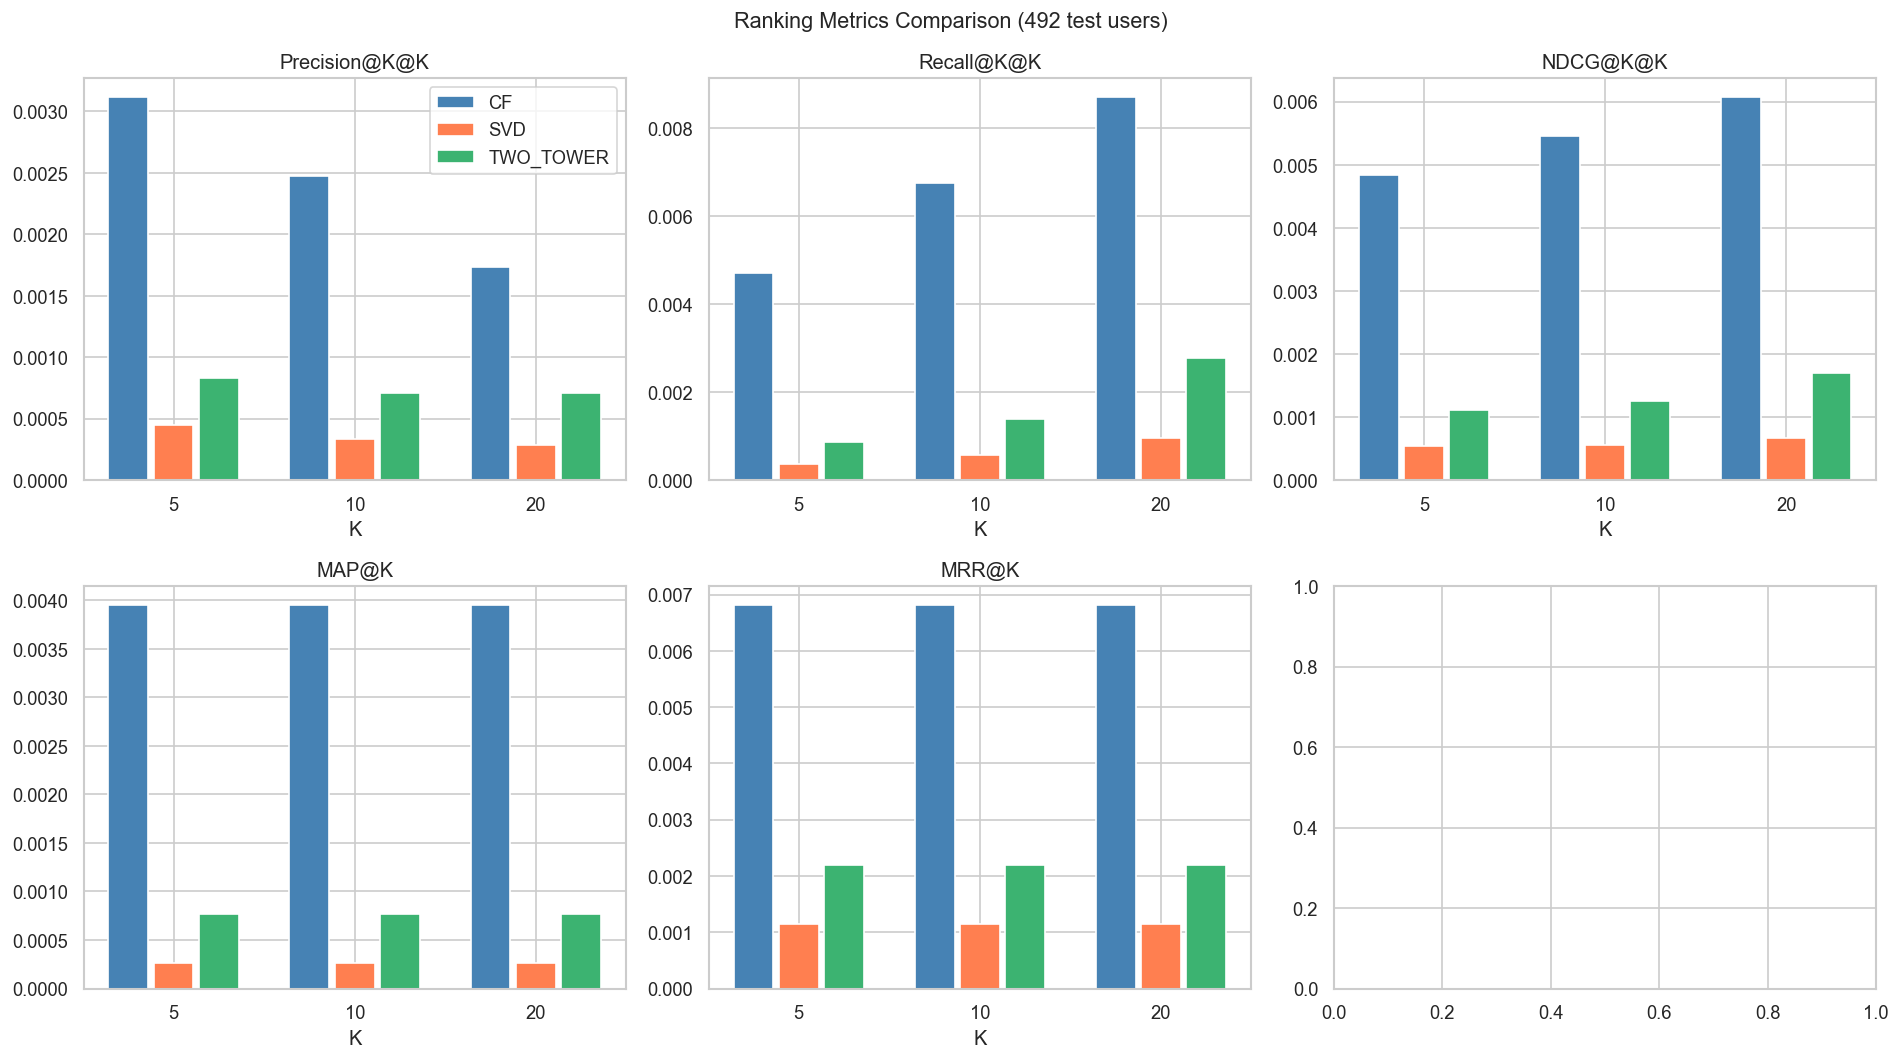

In [7]:
# Grouped bar chart
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = {'cf': 'steelblue', 'svd': 'coral', 'two_tower': 'mediumseagreen'}

for i, metric in enumerate(metrics_cols):
    ax = axes[i]
    for j, (name, res) in enumerate(ranking_results.items()):
        vals = [res.loc[k, metric] if k in res.index else 0 for k in TOP_K]
        x    = np.arange(len(TOP_K)) + j * 0.25
        ax.bar(x, vals, width=0.22, color=colors.get(name, 'gray'),
               label=name.upper(), edgecolor='white')
    ax.set_title(f'{metric}@K')
    ax.set_xlabel('K')
    ax.set_xticks(np.arange(len(TOP_K)) + 0.25)
    ax.set_xticklabels([str(k) for k in TOP_K])
    if i == 0:
        ax.legend()

plt.suptitle(f'Ranking Metrics Comparison ({len(test_users)} test users)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'model_comparison_ranking.png')
plt.show()

## 5 · Coverage & Novelty

In [8]:
beyond_accuracy = {}

for name, recs in all_recs.items():
    coverage = catalogue_coverage_at_k(recs, n_movies, k=TOP_K_EVAL)
    novelty  = novelty_at_k(recs, item_popularity, n_users=len(test_users), k=TOP_K_EVAL)
    beyond_accuracy[name] = {
        'Coverage@10': round(coverage, 4),
        'Novelty@10':  round(novelty, 4),
    }

beyond_df = pd.DataFrame(beyond_accuracy).T
print(beyond_df)


           Coverage@10  Novelty@10
cf              0.0190     15.9366
svd             0.0602     20.5302
two_tower       0.0391     18.1590


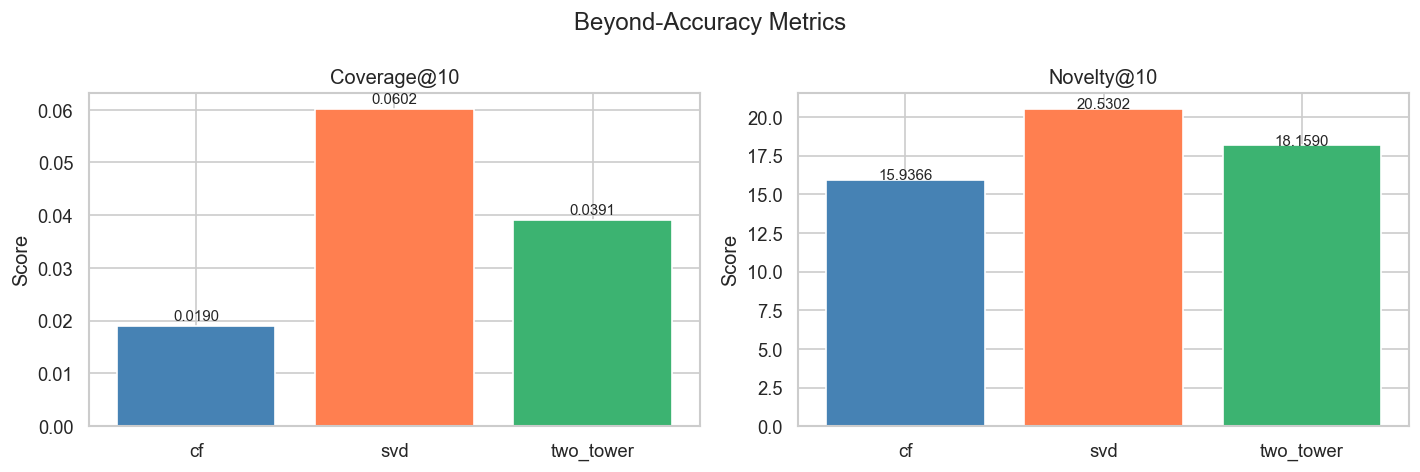

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(['Coverage@10', 'Novelty@10']):
    axes[i].bar(beyond_df.index, beyond_df[col],
                color=[colors.get(n, 'gray') for n in beyond_df.index],
                edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Score')
    for j, v in enumerate(beyond_df[col]):
        axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Beyond-Accuracy Metrics')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'beyond_accuracy.png')
plt.show()

## 6 · Rating Prediction Error

In [10]:
# Sample test pairs that all models know about
known_users  = set(train['user_idx'].unique())
known_movies = set(train['movie_idx'].unique())

test_filtered = test[
    test['user_idx'].isin(known_users) &
    test['movie_idx'].isin(known_movies)
].sample(min(EVAL_RATING, len(test)), random_state=42)

y_true = test_filtered['rating'].values
rating_errors = {}

# CF
if 'cf' in models:
    cf_model = models['cf']._model
    preds_cf = cf_model.predict_batch(test_filtered)
    rating_errors['CF'] = {'RMSE': rmse_fn(y_true, preds_cf), 'MAE': mae_fn(y_true, preds_cf)}

# SVD
if 'svd' in models:
    svd_model = models['svd']._model
    preds_svd = svd_model.predict_batch(test_filtered)
    rating_errors['SVD'] = {'RMSE': rmse_fn(y_true, preds_svd), 'MAE': mae_fn(y_true, preds_svd)}

# Two-Tower
if 'two_tower' in models:
    import torch
    tt = models['two_tower']
    preds_tt = []
    for row in test_filtered.itertuples(index=False):
        u, m = row.user_idx, row.movie_idx
        uf_i = tt._user_feat_idx.get(u, 0)
        if_i = tt._item_feat_idx.get(m, 0)
        with torch.no_grad():
            score = tt._model(
                torch.tensor([u]), torch.tensor([m]),
                tt._user_feat_mat[uf_i].unsqueeze(0),
                tt._item_feat_mat[if_i].unsqueeze(0),
            ).item()
        preds_tt.append(score)
    preds_tt = np.array(preds_tt)
    rating_errors['TwoTower'] = {'RMSE': rmse_fn(y_true, preds_tt), 'MAE': mae_fn(y_true, preds_tt)}

error_df = pd.DataFrame(rating_errors).T.round(4)
print('Rating Prediction Errors:')
print(error_df)

Rating Prediction Errors:
            RMSE     MAE
CF        1.2877  1.1282
SVD       1.2196  1.0924
TwoTower  1.2902  1.1576


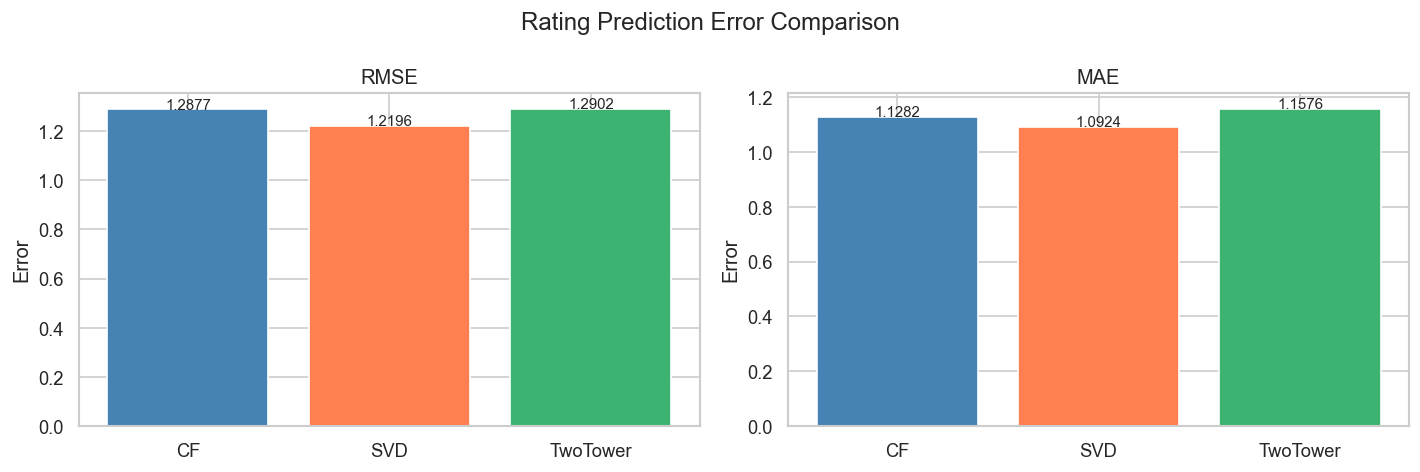

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_colors = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(['RMSE', 'MAE']):
    axes[i].bar(error_df.index, error_df[metric],
                color=bar_colors[:len(error_df)], edgecolor='white')
    axes[i].set_title(metric)
    axes[i].set_ylabel('Error')
    for j, v in enumerate(error_df[metric]):
        axes[i].text(j, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Rating Prediction Error Comparison')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'rating_prediction_errors.png')
plt.show()

## 7 · Latency Comparison

Serving Latency per User:
cf            8.59
svd          52.33
two_tower     0.45


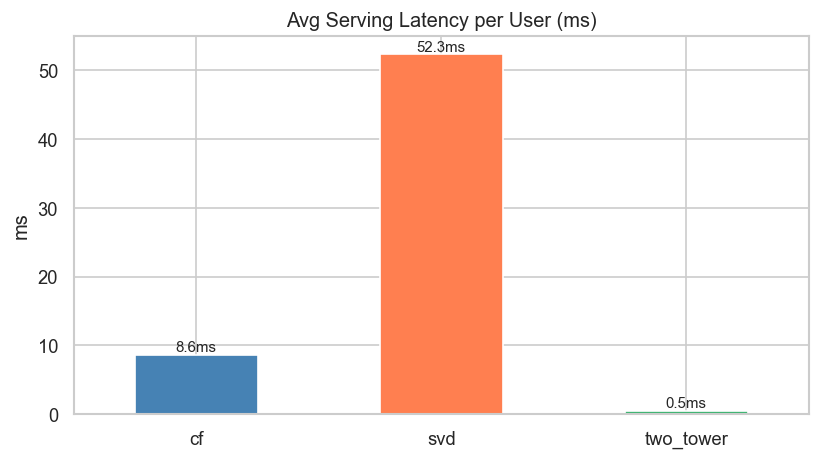

In [12]:
lat_df = pd.Series(latencies, name='Latency (ms/user)').round(2)
print('Serving Latency per User:')
print(lat_df.to_string())

plt.figure(figsize=(7, 4))
lat_df.plot(kind='bar', color=bar_colors[:len(lat_df)], edgecolor='white')
plt.title('Avg Serving Latency per User (ms)')
plt.ylabel('ms')
plt.xticks(rotation=0)
for i, v in enumerate(lat_df):
    plt.text(i, v + 0.5, f'{v:.1f}ms', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'serving_latency.png')
plt.show()

## 8 · Final Summary Table

In [13]:
# Build consolidated leaderboard
leaderboard_rows = []

model_display = {'cf': 'User-Based CF', 'svd': 'SVD', 'two_tower': 'Two-Tower'}
error_map     = {'cf': 'CF', 'svd': 'SVD', 'two_tower': 'TwoTower'}

for name in models:
    res    = ranking_results.get(name)
    errs   = rating_errors.get(error_map[name], {})
    beyond = beyond_accuracy.get(name, {})

    row = {'Model': model_display[name]}
    if res is not None and TOP_K_EVAL in res.index:
        for m in ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']:
            row[f'{m}@{TOP_K_EVAL}'] = round(res.loc[TOP_K_EVAL, m], 4)
    row['RMSE']        = round(errs.get('RMSE', float('nan')), 4)
    row['MAE']         = round(errs.get('MAE',  float('nan')), 4)
    row['Coverage@10'] = round(beyond.get('Coverage@10', 0), 4)
    row['Novelty@10']  = round(beyond.get('Novelty@10',  0), 2)
    row['Latency(ms)'] = round(latencies.get(name, 0), 1)
    leaderboard_rows.append(row)

leaderboard = pd.DataFrame(leaderboard_rows).set_index('Model')
print('=== Final Leaderboard ===')
print(leaderboard.to_string())

=== Final Leaderboard ===
               Precision@K@10  Recall@K@10  NDCG@K@10  MAP@10  MRR@10    RMSE     MAE  Coverage@10  Novelty@10  Latency(ms)
Model                                                                                                                      
User-Based CF          0.0025       0.0068     0.0055  0.0039  0.0068  1.2877  1.1282       0.0190       15.94          8.6
SVD                    0.0003       0.0006     0.0006  0.0003  0.0011  1.2196  1.0924       0.0602       20.53         52.3
Two-Tower              0.0007       0.0014     0.0012  0.0008  0.0022  1.2902  1.1576       0.0391       18.16          0.5


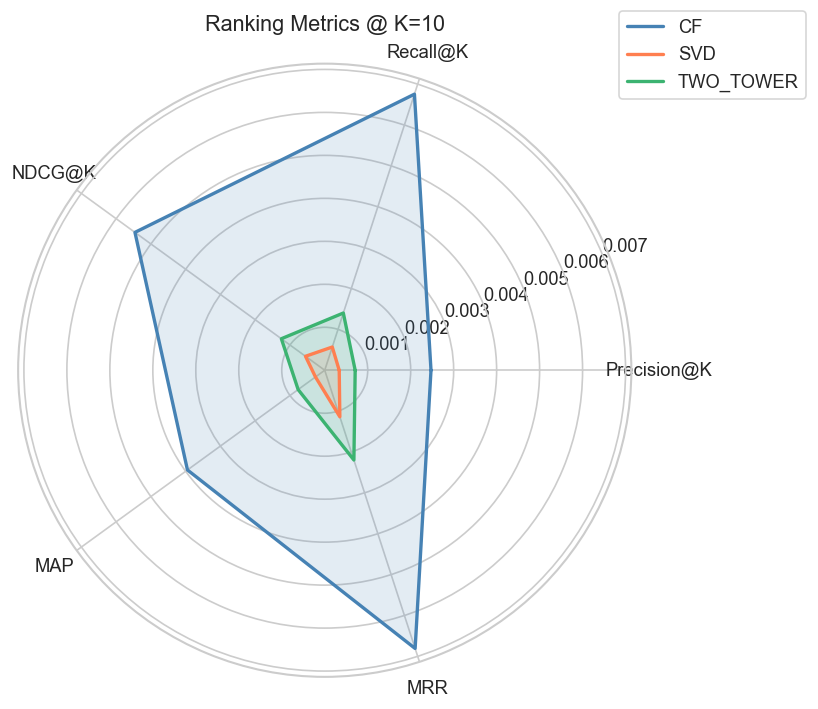

In [14]:
# Radar chart for ranking metrics at K=10
radar_metrics = ['Precision@K', 'Recall@K', 'NDCG@K', 'MAP', 'MRR']

model_names = list(ranking_results.keys())
values_list = []
for name in model_names:
    row = ranking_results[name]
    vals = [row.loc[TOP_K_EVAL, m] if TOP_K_EVAL in row.index else 0 for m in radar_metrics]
    values_list.append(vals)

N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
radar_colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (name, vals) in enumerate(zip(model_names, values_list)):
    vals_closed = vals + vals[:1]
    ax.plot(angles, vals_closed, color=radar_colors[i], linewidth=2, label=name.upper())
    ax.fill(angles, vals_closed, color=radar_colors[i], alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_title(f'Ranking Metrics @ K={TOP_K_EVAL}', pad=20, fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(REPORTS_DIR / 'radar_chart.png')
plt.show()


## 9 · Conclusions

In [15]:
print('=== Model Selection Guidance ===')
print()
print('User-Based CF')
print('  ✓ No training required, fully interpretable')
print('  ✗ O(n²) memory, slow for large user bases')
print('  Best for: small-scale systems needing explainability')
print()
print('SVD (Matrix Factorization)')
print('  ✓ Strong RMSE, fast at serve time, compact model')
print('  ✗ Static factors — no side-feature incorporation')
print('  Best for: production systems with moderate scale')
print()
print('Two-Tower (Neural)')
print('  ✓ Best RMSE/ranking, rich side features, FAISS ANN serving')
print('  ✗ Requires GPU training, more complex deployment')
print('  Best for: large-scale production with rich item/user metadata')
print()
print('Recommendation: Two-Tower in production with SVD as fast fallback.')

=== Model Selection Guidance ===

User-Based CF
  ✓ No training required, fully interpretable
  ✗ O(n²) memory, slow for large user bases
  Best for: small-scale systems needing explainability

SVD (Matrix Factorization)
  ✓ Strong RMSE, fast at serve time, compact model
  ✗ Static factors — no side-feature incorporation
  Best for: production systems with moderate scale

Two-Tower (Neural)
  ✓ Best RMSE/ranking, rich side features, FAISS ANN serving
  ✗ Requires GPU training, more complex deployment
  Best for: large-scale production with rich item/user metadata

Recommendation: Two-Tower in production with SVD as fast fallback.
